<a href="https://colab.research.google.com/github/Lagnadeep-samal/Machine-learning-models/blob/main/Roc_Aucimplementation_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import numpy as np
import seaborn as sns

In [3]:
X,y=load_breast_cancer(return_X_y=True)
X.shape

(569, 30)

In [4]:
y.shape

(569,)

In [5]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42)
model=LogisticRegression()
model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [11]:
y_pred_lr=model.predict(X_test)

In [6]:
y_prob_lr=model.predict_proba(X_test)[:,-1]
y_prob_lr

array([8.38102207e-01, 3.24417118e-10, 9.70830897e-04, 9.95531599e-01,
       9.99101529e-01, 8.43099570e-11, 6.03662778e-14, 6.32026149e-03,
       9.98629423e-01, 9.82991980e-01, 9.51888426e-01, 2.69188170e-04,
       9.89549327e-01, 1.84827987e-01, 9.97672152e-01, 7.40342322e-04,
       9.96584211e-01, 9.99559536e-01, 9.98405080e-01, 1.68920684e-08,
       7.91211956e-01, 9.84487572e-01, 5.40819482e-11, 9.95350085e-01,
       9.88713396e-01, 9.99372051e-01, 9.96077002e-01, 9.90562286e-01,
       9.93736420e-01, 8.56373055e-10, 9.93800790e-01, 9.98774517e-01,
       9.84631144e-01, 9.70181297e-01, 9.98073905e-01, 9.94999984e-01,
       1.99140001e-03, 9.95709374e-01, 5.85858343e-07, 7.81410480e-01,
       9.97226611e-01, 7.59002399e-04, 9.98231633e-01, 9.86960730e-01,
       9.98398594e-01, 9.51212291e-01, 9.98634967e-01, 9.90067093e-01,
       9.19665950e-01, 9.95305967e-01, 1.66807654e-05, 1.94496072e-10,
       8.71457450e-01, 9.99129552e-01, 9.98195794e-01, 9.72893265e-01,
      

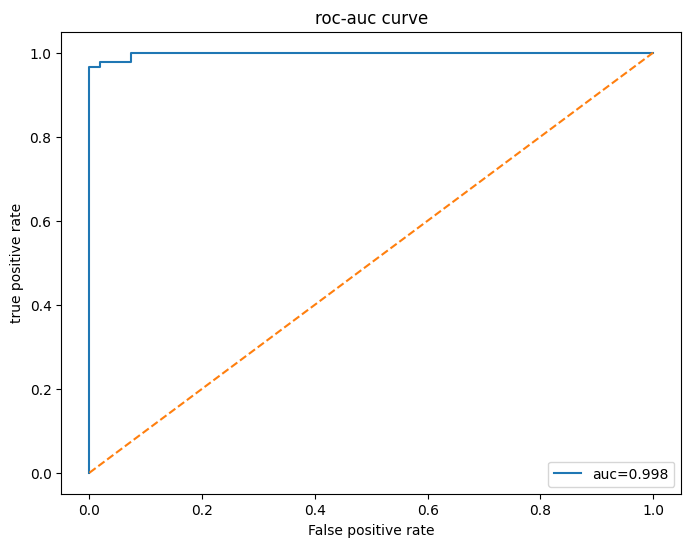

In [8]:
from sklearn.metrics import roc_auc_score,roc_curve

fpr,tpr,threshold=roc_curve(y_test,y_prob_lr)
auc_score=roc_auc_score(y_test,y_prob_lr)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,label=f'auc={auc_score:.3f}')
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel('False positive rate')
plt.ylabel('true positive rate')
plt.title("roc-auc curve")
plt.legend()
plt.show()


In [12]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred_lr)
cm


array([[51,  3],
       [ 2, 87]])

In [14]:
tn,fp,fn,tp=cm.ravel()
print("True Negatives (TN):", tn)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)
print("True Positives (TP):", tp)




True Negatives (TN): 51
False Positives (FP): 3
False Negatives (FN): 2
True Positives (TP): 87


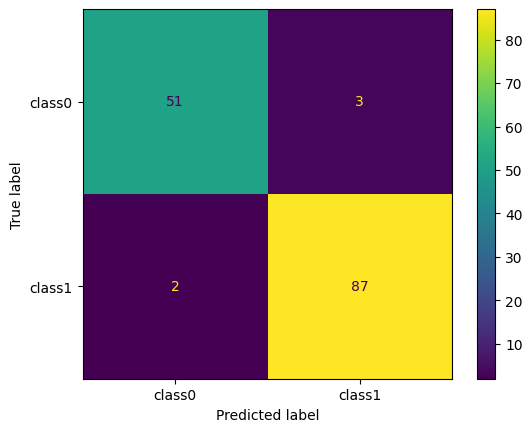

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay
display=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['class0','class1'])
display.plot()


[[50  4]
 [ 0 89]]
[[51  3]
 [ 2 87]]
[[54  0]
 [ 3 86]]


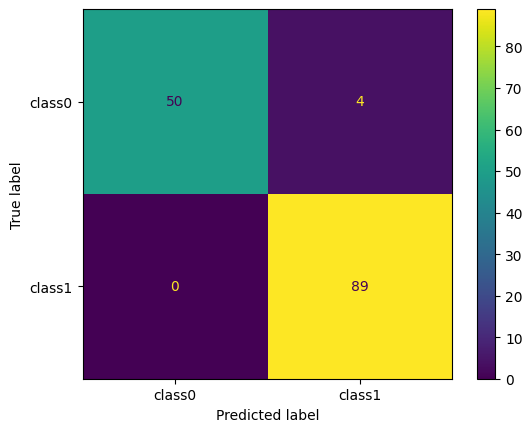

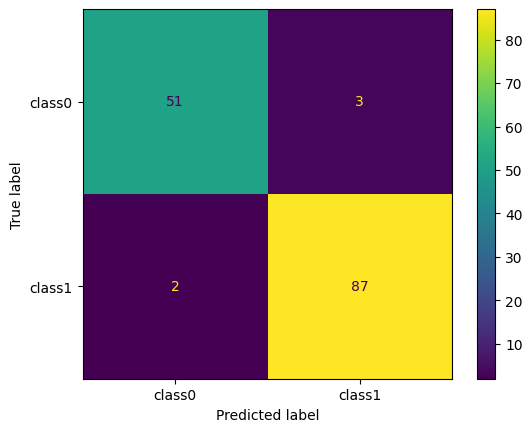

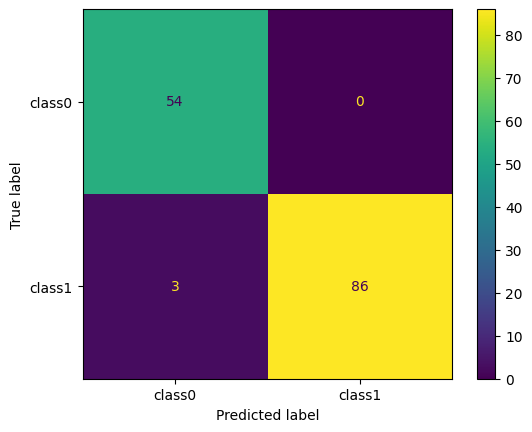

In [19]:
thresholds=[0.2,0.5,0.8]
y_prob=model.predict_proba(X_test)[:,1]
for threshold in thresholds:
  y_pred=(y_prob>=threshold).astype(int)
  cm=confusion_matrix(y_test,y_pred)
  print(cm)
  display=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['class0','class1'])
  display.plot()

